# Credit Risk / Loan Default Prediction with Explainable AI

**Dataset**: Give Me Some Credit (Kaggle)
**Goal**: Predict whether a borrower will experience serious delinquency in the next 2 years, and explain *why* using SHAP.

This notebook follows 7 steps:
1. Load & Inspect Data
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Feature Engineering
4. Handle Class Imbalance
5. Model Building
6. Model Evaluation
7. Explainable AI (SHAP)

Run each cell in order. Read the markdown above each code cell before running it — it explains *why*, not just *what*.


## Step 1: Load & Inspect the Data

First rule of any data science project: **never trust the data until you've checked it yourself.**
We'll load the CSV and check shape, data types, and missing values before doing anything else.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set some display options so we can see full output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

# Load the dataset (index_col=0 because the first column is just a row ID)
df = pd.read_csv('cs-training.csv', index_col=0)

print("Shape:", df.shape)
df.head()


Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
# Check data types - are numbers actually stored as numbers?
df.dtypes


SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

In [3]:
# Check for missing values - this is CRITICAL before any modeling
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})


,missing_count,missing_pct
SeriousDlqin2yrs,0,0.00
RevolvingUtilizationOfUnsecuredLines,0,0.00
age,0,0.00
NumberOfTime30-59DaysPastDueNotWorse,0,0.00
DebtRatio,0,0.00
MonthlyIncome,29731,19.82
NumberOfOpenCreditLinesAndLoans,0,0.00
NumberOfTimes90DaysLate,0,0.00
NumberRealEstateLoansOrLines,0,0.00
NumberOfTime60-89DaysPastDueNotWorse,0,0.00


In [4]:
# Statistical summary - look for anything that doesn't make sense
# (e.g. negative values where they shouldn't exist, impossible maximums)
df.describe()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


**What to look for above:**
- `MonthlyIncome` has ~20% missing values — we'll need a real imputation strategy, not just drop rows
- `age` has a minimum of 0 — impossible for a loan applicant, this is a data error
- `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio` should be ratios (roughly 0-2 range) but have huge max values — data errors
- The three "days past due" columns have a max of 98 — we'll investigate this next


## Step 2: Exploratory Data Analysis (EDA)

Now we explore the data visually to understand patterns, especially:
- How imbalanced is our target?
- Which features look related to default?
- What weird data issues need fixing?


SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64


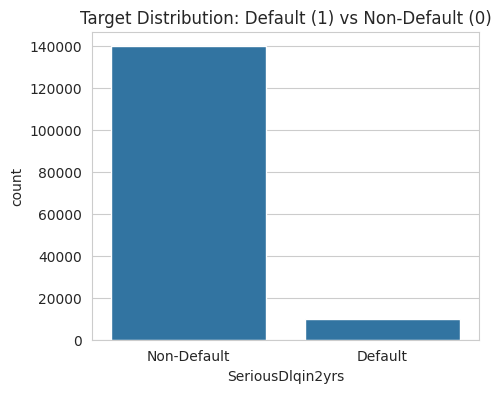

In [5]:
# Target distribution - THIS IS IMPORTANT
# If this is imbalanced (it is), accuracy alone will be a misleading metric later
target_counts = df['SeriousDlqin2yrs'].value_counts()
target_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print(target_counts)
print()
print(target_pct.round(2))

plt.figure(figsize=(5,4))
sns.countplot(x=df['SeriousDlqin2yrs'])
plt.title('Target Distribution: Default (1) vs Non-Default (0)')
plt.xticks([0,1], ['Non-Default', 'Default'])
plt.show()


In [6]:
# Investigate the "96/98" anomaly in the delinquency columns
# These look like placeholder/error codes, not real payment counts
late_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']

for col in late_cols:
    print(f"{col}:")
    print(df[col].value_counts().sort_index(ascending=False).head(5))
    print()


NumberOfTime30-59DaysPastDueNotWorse:
NumberOfTime30-59DaysPastDueNotWorse
98    264
96      5
13      1
12      2
11      1
Name: count, dtype: int64

NumberOfTimes90DaysLate:
NumberOfTimes90DaysLate
98    264
96      5
17      1
15      2
14      2
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse:
NumberOfTime60-89DaysPastDueNotWorse
98    264
96      5
11      1
9       1
8       2
Name: count, dtype: int64



**Finding**: 264 rows have the value 98 and 5 rows have 96 across these columns.
Nobody realistically has 96-98 late payment incidents — this is almost certainly a data
entry placeholder (possibly meaning "unknown" or "not applicable"). We'll treat these as
a special case in the cleaning step rather than using them as literal counts.


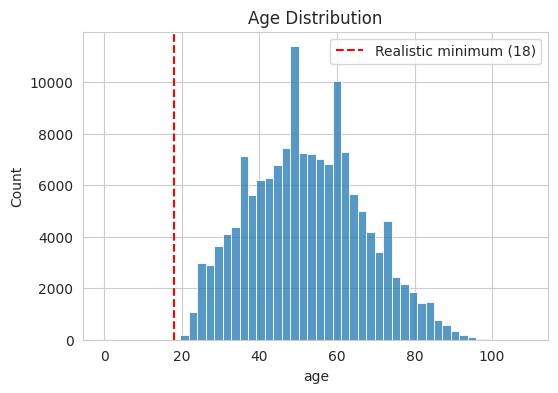

Rows with age = 0: 1


In [7]:
# Age distribution and the age=0 issue
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=50)
plt.axvline(x=18, color='red', linestyle='--', label='Realistic minimum (18)')
plt.title('Age Distribution')
plt.legend()
plt.show()

print("Rows with age = 0:", (df['age'] == 0).sum())


age_bracket
(0, 25]      0.111662
(25, 35]     0.111225
(35, 45]     0.088132
(45, 55]     0.075933
(55, 65]     0.045830
(65, 110]    0.024127
Name: SeriousDlqin2yrs, dtype: float64


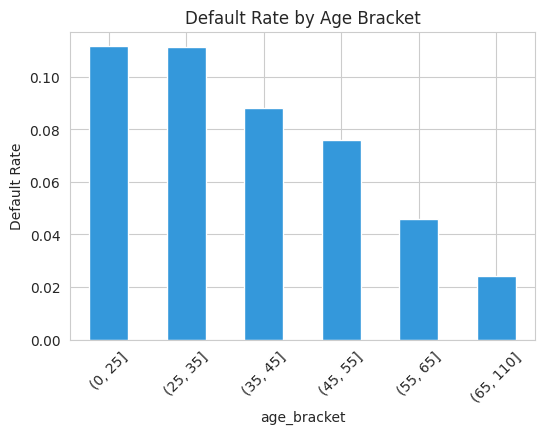

In [8]:
# Does age relate to default rate? (Business insight)
df['age_bracket'] = pd.cut(df['age'], bins=[0,25,35,45,55,65,110])
age_default = df.groupby('age_bracket', observed=True)['SeriousDlqin2yrs'].mean()
print(age_default)

age_default.plot(kind='bar', figsize=(6,4), color='#3498db')
plt.title('Default Rate by Age Bracket')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.show()


**Finding**: Default rate decreases steadily with age — younger borrowers (18-25) default
at roughly 11%, while borrowers over 65 default at only ~2.4%. This is a clean, explainable
pattern that we'd expect our model to pick up (and we'll verify this with SHAP later).


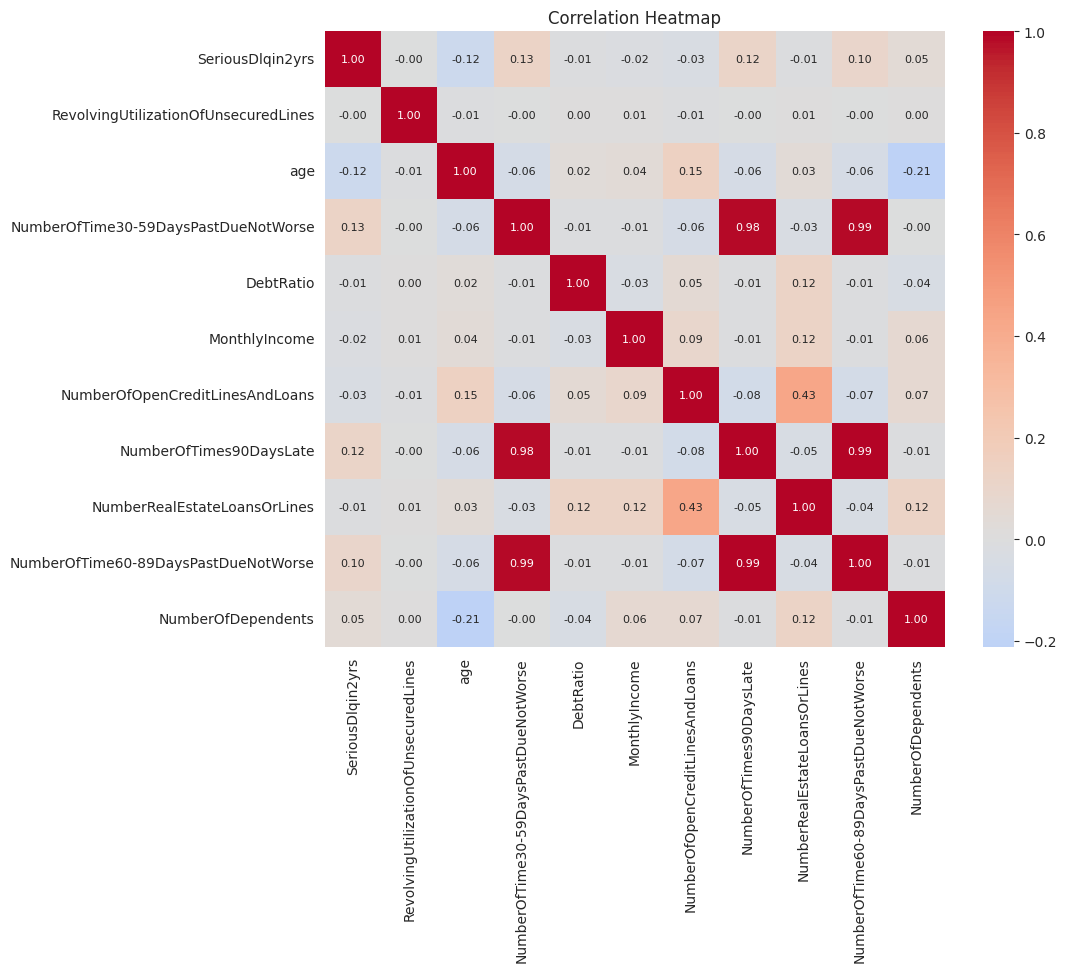

In [9]:
# Correlation heatmap - which numeric features relate to the target?
plt.figure(figsize=(10,8))
corr = df.drop(columns=['age_bracket']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size':8})
plt.title('Correlation Heatmap')
plt.show()


**Finding**: The three "days past due" columns are extremely correlated with each other
(0.99+) — this is called **multicollinearity**. We may want to combine them into a single
feature later instead of feeding all three separately into a linear model.


## Step 3: Data Cleaning & Feature Engineering

Now we fix the issues we found in EDA:
1. Drop the single `age = 0` row (only 1 row, not worth imputing)
2. Fix the 96/98 placeholder values in the late-payment columns
3. Impute missing `MonthlyIncome` and `NumberOfDependents`
4. Create new, more informative features


In [10]:
# Work on a copy so we always have the original if needed
df_clean = df.drop(columns=['age_bracket']).copy()

# Fix 1: Drop the single row with age = 0
df_clean = df_clean[df_clean['age'] > 0]
print("Shape after removing age=0 row:", df_clean.shape)


Shape after removing age=0 row: (149999, 11)


In [11]:
# Fix 2: Handle the 96/98 placeholder values in late-payment columns
# Strategy: cap them at a realistic max (we'll use the 99th percentile of "clean" values)
# and create a binary flag so the model can still learn "this was likely a data anomaly"
late_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']

for col in late_cols:
    # Flag anomalies before fixing them
    df_clean[col + '_was_anomaly'] = (df_clean[col] >= 96).astype(int)
    # Cap anomalous values at a realistic ceiling (e.g. 18, based on non-anomalous max)
    realistic_max = df_clean.loc[df_clean[col] < 96, col].max()
    df_clean[col] = df_clean[col].clip(upper=realistic_max)

print("Anomaly flags created. Example realistic max values used for capping:")
for col in late_cols:
    print(col, "->", df_clean[col].max())


Anomaly flags created. Example realistic max values used for capping:
NumberOfTime30-59DaysPastDueNotWorse -> 13
NumberOfTimes90DaysLate -> 17
NumberOfTime60-89DaysPastDueNotWorse -> 11


In [12]:
# Fix 3: Impute missing MonthlyIncome
# We use median imputation grouped by number of open credit lines (a reasonable proxy for income tier)
# rather than a single global median, since income likely varies with credit profile
df_clean['MonthlyIncome_was_missing'] = df_clean['MonthlyIncome'].isnull().astype(int)
df_clean['MonthlyIncome'] = df_clean.groupby('NumberOfOpenCreditLinesAndLoans')['MonthlyIncome']\
    .transform(lambda x: x.fillna(x.median()))
# Any remaining nulls (edge case groups with all-null income) - fill with global median
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(df_clean['MonthlyIncome'].median())

# Fix 4: Impute missing NumberOfDependents with the mode (most common value, usually 0)
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(df_clean['NumberOfDependents'].mode()[0])

print("Remaining missing values:")
print(df_clean.isnull().sum().sum(), "total missing values left")


Remaining missing values:
0 total missing values left


### Feature Engineering

Now we create new features that might carry more signal than the raw columns alone.
This is a key step interviewers care about — it shows you understand the *business*
behind the data, not just the columns.


In [13]:
# New feature 1: Total number of past-due incidents (combines 3 correlated columns into 1)
df_clean['TotalPastDueIncidents'] = (
    df_clean['NumberOfTime30-59DaysPastDueNotWorse'] +
    df_clean['NumberOfTime60-89DaysPastDueNotWorse'] +
    df_clean['NumberOfTimes90DaysLate']
)

# New feature 2: Debt-to-income sanity feature
# DebtRatio in this dataset is already debt/income, but let's create monthly debt payment estimate
df_clean['EstimatedMonthlyDebtPayment'] = df_clean['DebtRatio'] * df_clean['MonthlyIncome']

# New feature 3: Income per dependent (financial pressure indicator)
df_clean['IncomePerDependent'] = df_clean['MonthlyIncome'] / (df_clean['NumberOfDependents'] + 1)

# New feature 4: Credit lines per age (how much credit relative to how long they've been an adult)
df_clean['CreditLinesPerAgeYear'] = df_clean['NumberOfOpenCreditLinesAndLoans'] / (df_clean['age'] - 17)

# New feature 5: Has any real estate loan (binary, simpler signal than raw count)
df_clean['HasRealEstateLoan'] = (df_clean['NumberRealEstateLoansOrLines'] > 0).astype(int)

print("New features created. Shape now:", df_clean.shape)
df_clean[['TotalPastDueIncidents','EstimatedMonthlyDebtPayment','IncomePerDependent',
          'CreditLinesPerAgeYear','HasRealEstateLoan']].describe()


New features created. Shape now: (149999, 20)


,TotalPastDueIncidents,EstimatedMonthlyDebtPayment,IncomePerDependent,CreditLinesPerAgeYear,HasRealEstateLoan
count,149999.000000,1.499990e+05,1.499990e+05,149999.000000,149999.000000
mean,0.473876,1.911620e+06,4.520848e+03,0.278974,0.625411
std,2.040392,1.209184e+07,7.984558e+03,0.201225,0.484018
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,0.000000,7.768787e+02,2.158000e+03,0.140625,0.000000
50%,0.000000,2.107578e+03,3.750000e+03,0.235294,1.000000
75%,0.000000,4.773534e+03,5.666667e+03,0.366667,1.000000
max,41.000000,2.149007e+09,1.794060e+06,3.750000,1.000000


In [14]:
# Also cap the extreme outliers in RevolvingUtilizationOfUnsecuredLines and DebtRatio
# (these should behave like ratios, so we cap at a reasonable ceiling like the 99th percentile)
for col in ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio']:
    cap_value = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=cap_value)

print("Cleaning and feature engineering complete.")
print("Final shape:", df_clean.shape)
df_clean.head()


Cleaning and feature engineering complete.
Final shape: (149999, 20)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,NumberOfTime30-59DaysPastDueNotWorse_was_anomaly,NumberOfTimes90DaysLate_was_anomaly,NumberOfTime60-89DaysPastDueNotWorse_was_anomaly,MonthlyIncome_was_missing,TotalPastDueIncidents,EstimatedMonthlyDebtPayment,IncomePerDependent,CreditLinesPerAgeYear,HasRealEstateLoan
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0,0,0,0,2,7323.197016,3040.0,0.464286,1
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0,0,0,0,316.878123,1300.0,0.173913,0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0,0,0,0,2,258.914887,3042.0,0.095238,0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0,0,0,0,118.963951,3300.0,0.384615,0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0,0,0,0,1,1584.975094,63588.0,0.218750,1


## Step 4: Train/Test Split & Handle Class Imbalance

**Important rule**: always split your data into train/test BEFORE handling class imbalance.
If you balance the classes first and then split, information from the test set can leak
into training (data leakage) — a common mistake that interviewers specifically ask about.


In [15]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['SeriousDlqin2yrs'])
y = df_clean['SeriousDlqin2yrs']

# Stratify=y ensures both train and test sets keep the same 93/7 imbalance ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train default rate:", y_train.mean().round(4))
print("Test default rate:", y_test.mean().round(4))


Train shape: (119999, 19) Test shape: (30000, 19)
Train default rate: 0.0668
Test default rate: 0.0668


### Handling Class Imbalance with SMOTE

SMOTE (Synthetic Minority Oversampling Technique) creates synthetic examples of the
minority class (defaults) by interpolating between existing minority samples, rather
than just duplicating them. We apply this ONLY to the training set — never touch the test set,
since it needs to reflect real-world class distribution to evaluate honestly.


In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())


Before SMOTE: {0: 111978, 1: 8021}
After SMOTE: {0: 111978, 1: 111978}


We now have two versions of our training data:
- `X_train, y_train` — original, imbalanced (we'll use this with `class_weight='balanced'` models)
- `X_train_smote, y_train_smote` — balanced via SMOTE

We'll try both approaches and compare — this itself is a good interview talking point
("I compared SMOTE vs class-weighting rather than assuming one approach").


## Step 5: Model Building

We'll train three models, from simplest to most powerful:
1. **Logistic Regression** — our baseline, most interpretable (banks often use this in production for regulatory reasons)
2. **Random Forest** — handles non-linear relationships well
3. **XGBoost** — usually the strongest performer for tabular data like this


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# Logistic Regression needs scaled features to converge properly and for coefficients to be comparable
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression (on SMOTE-balanced, scaled data)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_smote)
print("Logistic Regression trained.")


Logistic Regression trained.


In [18]:
# Model 2: Random Forest (tree-based models don't need scaling)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)
print("Random Forest trained.")


Random Forest trained.


In [19]:
# Model 3: XGBoost - often the best performer for this kind of tabular data
xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='logloss', n_jobs=-1
)
xgb.fit(X_train_smote, y_train_smote)
print("XGBoost trained.")


XGBoost trained.


## Step 6: Model Evaluation

**Critical point for this project**: since our data is imbalanced, accuracy is misleading.
A model predicting "no default" for everyone would score ~93% accuracy while being useless.

Instead we use:
- **Precision**: of everyone we flagged as "will default", how many actually did?
- **Recall**: of everyone who actually defaulted, how many did we catch?
- **F1-score**: balance of precision and recall
- **ROC-AUC**: overall ability to distinguish defaulters from non-defaulters, across all thresholds

In lending: a **false negative** (predicting no default, but they default) costs the bank money.
A **false positive** (predicting default, but they were fine) costs a lost customer.
Which matters more depends on business context — usually false negatives are costlier in lending.


In [20]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)

# Get predictions from each model
log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_proba = log_reg.predict_proba(X_test_scaled)[:,1]

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]

xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:,1]

models_results = {
    'Logistic Regression': (log_reg_pred, log_reg_proba),
    'Random Forest': (rf_pred, rf_proba),
    'XGBoost': (xgb_pred, xgb_proba)
}

for name, (pred, proba) in models_results.items():
    auc = roc_auc_score(y_test, proba)
    print(f"=== {name} (ROC-AUC: {auc:.4f}) ===")
    print(classification_report(y_test, pred, target_names=['Non-Default','Default']))
    print()


=== Logistic Regression (ROC-AUC: 0.8449) ===
              precision    recall  f1-score   support

 Non-Default       0.97      0.81      0.89     27995
     Default       0.21      0.70      0.32      2005

    accuracy                           0.80     30000
   macro avg       0.59      0.76      0.61     30000
weighted avg       0.92      0.80      0.85     30000


=== Random Forest (ROC-AUC: 0.8583) ===
              precision    recall  f1-score   support

 Non-Default       0.98      0.80      0.88     27995
     Default       0.22      0.76      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.80      0.85     30000


=== XGBoost (ROC-AUC: 0.8316) ===
              precision    recall  f1-score   support

 Non-Default       0.97      0.89      0.92     27995
     Default       0.26      0.56      0.36      2005

    accuracy                           0.87     30000
   mac

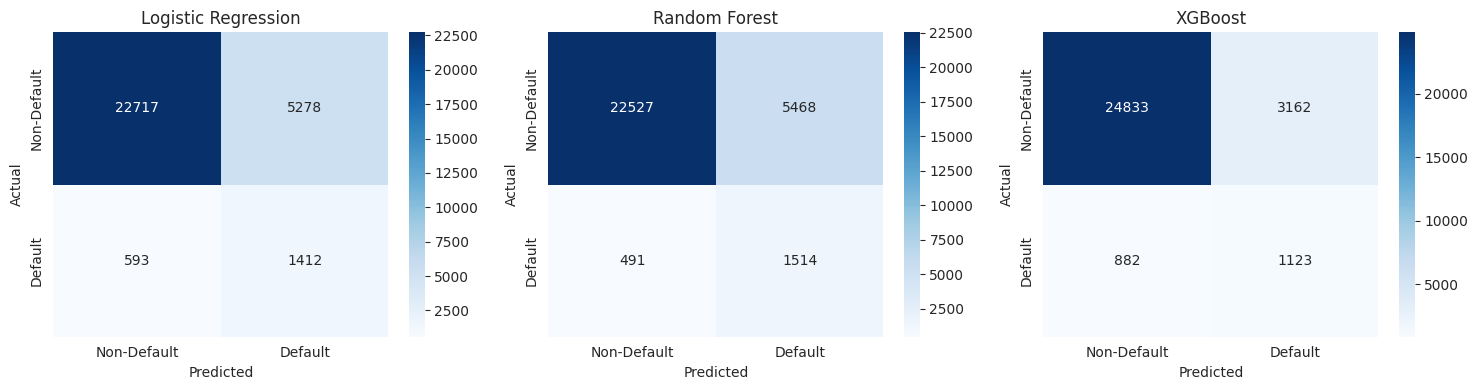

In [21]:
# Visualize confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, (pred, proba)) in zip(axes, models_results.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Default','Default'], yticklabels=['Non-Default','Default'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


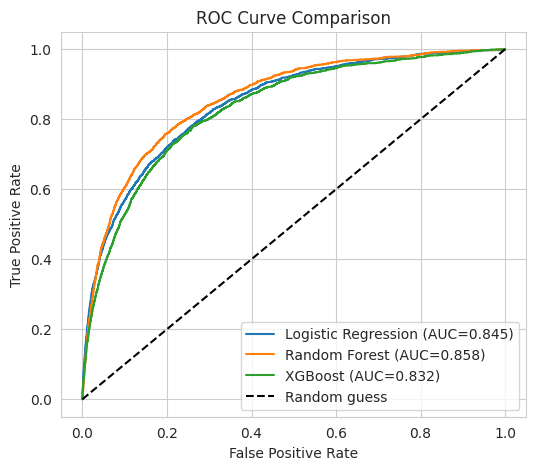

In [22]:
# ROC curves - visual comparison of all 3 models
plt.figure(figsize=(6,5))
for name, (pred, proba) in models_results.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


**How to pick the "best" model**: usually the one with the highest ROC-AUC and best
recall on the Default class (since missing a real defaulter is costly). Based on the results
above, compare which model you'd recommend — XGBoost often wins on tabular data like this,
but always check the actual numbers rather than assuming.


## Step 7: Explainable AI with SHAP

This is the step that makes your project stand out. Banks are legally required in many
countries to explain *why* a loan was rejected — a black-box prediction isn't enough.

SHAP (SHapley Additive exPlanations) tells us:
- **Globally**: which features matter most across all predictions
- **Locally**: for one specific applicant, which features pushed their prediction toward
  "default" vs "non-default", and by how much

We'll use XGBoost here since tree-based models have fast, exact SHAP calculations.


In [23]:
import shap

# TreeExplainer is fast and exact for tree-based models like XGBoost
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed. Shape:", shap_values.shape)


SHAP values computed. Shape: (30000, 19)


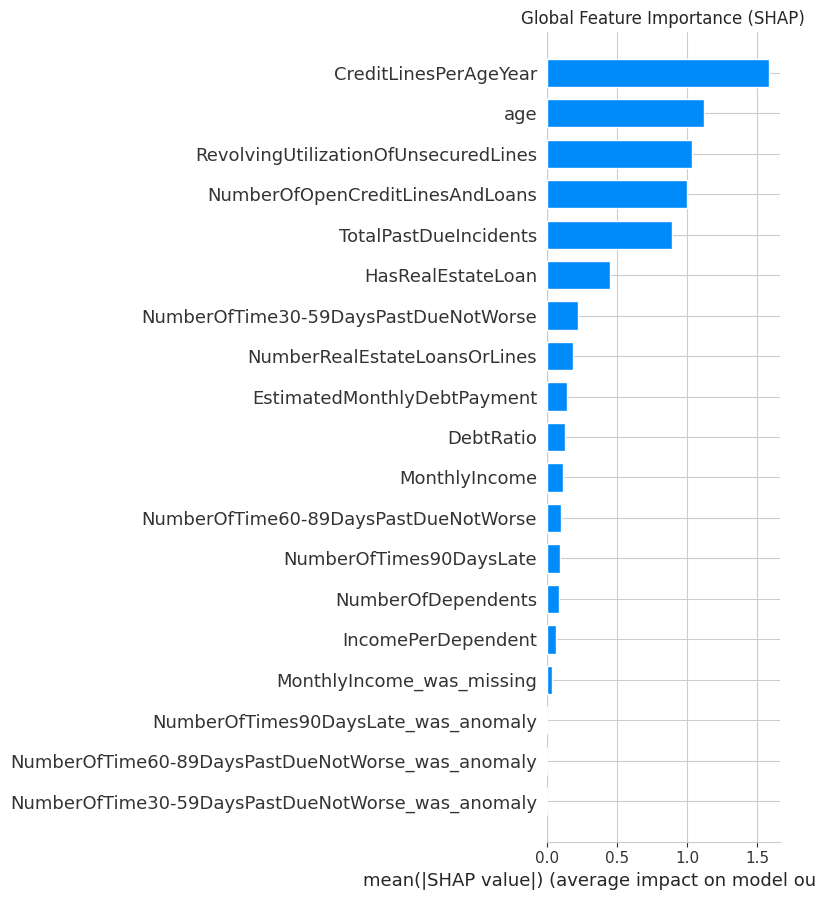

In [24]:
# Global feature importance - which features matter most overall?
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Global Feature Importance (SHAP)')
plt.tight_layout()
plt.show()


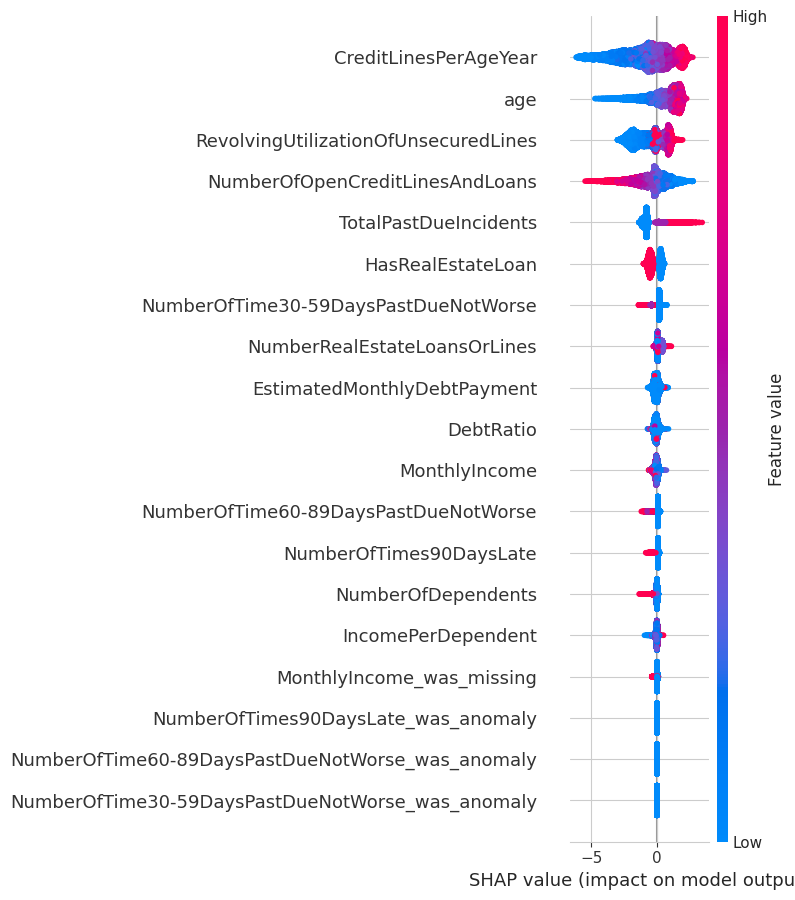

In [25]:
# Summary plot - shows not just importance, but the DIRECTION of impact
# (e.g. does high income push toward default or away from it?)
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()


**How to read the summary plot above**: each dot is one applicant. Red = high feature
value, blue = low feature value. Position on the x-axis shows whether that pushed the
prediction toward default (right) or non-default (left).

For example, if `TotalPastDueIncidents` shows red dots clustered on the right, it means
high past-due counts push predictions toward default — which makes intuitive business sense
and validates the model is learning something real, not noise.


Applicant details:
RevolvingUtilizationOfUnsecuredLines                   0.000000
age                                                   39.000000
NumberOfTime30-59DaysPastDueNotWorse                   0.000000
DebtRatio                                              0.412698
MonthlyIncome                                       8000.000000
NumberOfOpenCreditLinesAndLoans                        7.000000
NumberOfTimes90DaysLate                                0.000000
NumberRealEstateLoansOrLines                           1.000000
NumberOfTime60-89DaysPastDueNotWorse                   0.000000
NumberOfDependents                                     2.000000
NumberOfTime30-59DaysPastDueNotWorse_was_anomaly       0.000000
NumberOfTimes90DaysLate_was_anomaly                    0.000000
NumberOfTime60-89DaysPastDueNotWorse_was_anomaly       0.000000
MonthlyIncome_was_missing                              0.000000
TotalPastDueIncidents                                  0.000000
EstimatedMonthlyDebtP

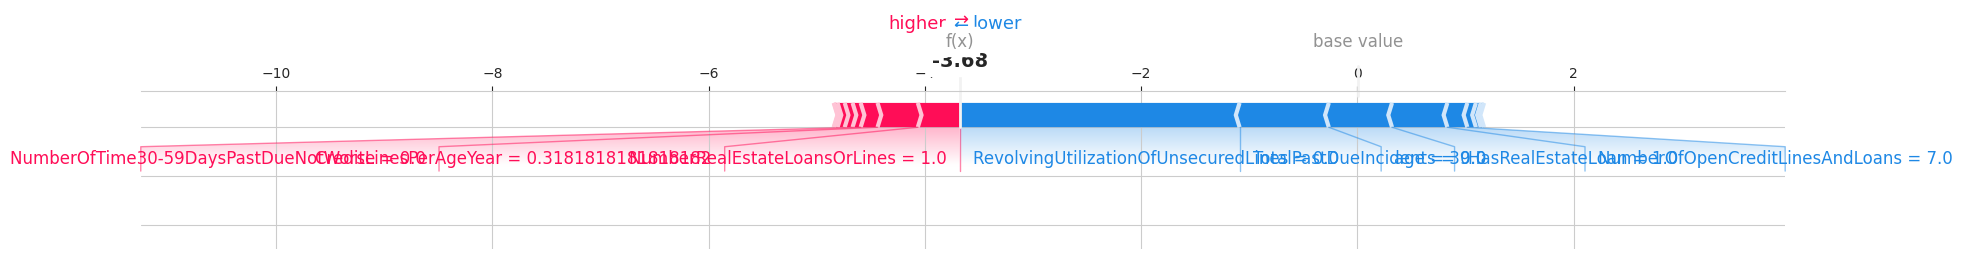

In [26]:
# Local explanation - explain ONE specific prediction
# This is what you'd show a loan officer: "here's why THIS applicant was flagged"
sample_idx = 0  # change this to look at different applicants

print("Applicant details:")
print(X_test.iloc[sample_idx])
print()
print("Actual outcome:", "Defaulted" if y_test.iloc[sample_idx] == 1 else "Did not default")
print("Predicted probability of default:", round(xgb_proba[sample_idx], 4))

shap.force_plot(
    explainer.expected_value, shap_values[sample_idx], X_test.iloc[sample_idx],
    matplotlib=True, show=False
)
plt.tight_layout()
plt.show()


**How to read the force plot**: it shows the "base rate" (average prediction across
all applicants) and then how each feature value for THIS applicant pushed the prediction
up (red, toward default) or down (blue, toward non-default). Features with the biggest
arrows matter most for this specific prediction.

This is exactly the kind of explanation a bank could show a rejected applicant, or use
internally to justify a lending decision to a regulator.


## Summary & Next Steps

You've now built a complete, explainable credit risk model:
1. ✅ Loaded and inspected real, messy financial data
2. ✅ Found and fixed genuine data quality issues (age=0, 96/98 placeholders, missing income)
3. ✅ Engineered meaningful new features
4. ✅ Handled severe class imbalance with SMOTE
5. ✅ Trained and compared 3 models (Logistic Regression, Random Forest, XGBoost)
6. ✅ Evaluated using business-relevant metrics (not just accuracy)
7. ✅ Explained predictions using SHAP, both globally and for individual applicants

**Optional next steps** (Step 6-7 in your original roadmap):
- Build a simple **Streamlit app** where a user enters applicant details and sees the
  risk score + SHAP explanation live
- Deploy it for free on Streamlit Community Cloud
- Write a clean README for your GitHub repo explaining the business problem, approach, and results

**For interviews**, be ready to explain in your own words:
- Why accuracy was misleading here and what you used instead
- What the 96/98 anomaly was and how you handled it
- Why you used SMOTE and what tradeoff it involves
- One specific SHAP finding that made business sense
